# Training Neural Network

## Building Micrograd

This is a library by Andrej Karapathy used to train the neural networks       

https://github.com/karpathy/micrograd       

A tiny Autograd engine (with a bite! :)). Implements backpropagation (reverse-mode autodiff) over a dynamically built DAG and a small neural networks library on top of it with a PyTorch-like API. Both are tiny, with about 100 and 50 lines of code respectively. The DAG only operates over scalar values, so e.g. we chop up each neuron into all of its individual tiny adds and multiplies. However, this is enough to build up entire deep neural nets doing binary classification, as the demo notebook shows. Potentially useful for educational purposes.

In [1]:
! pip install micrograd


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from micrograd.engine import Value

a = Value(-4.0)
b = Value(2.0)
c = a + b
d = a * b + b**3
c += c + 1
c += 1 + c + (-a)
d += d * 2 + (b + a).relu()
d += 3 * d + (b - a).relu()
e = c - d
f = e**2
g = f / 2.0
g += 10.0 / f
print(f"{g.data:.4f}")  # prints 24.7041, the outcome of this forward pass
g.backward()
print(f"{a.grad:.4f}")  # prints 138.8338, i.e. the numerical value of dg/da
print(f"{b.grad:.4f}")  # prints 645.5773, i.e. the numerical value of dg/db

24.7041
138.8338
645.5773


The above values build a tree for each new operation and it does not replace the previous values rather adds the operation to the node, creating a mathematical equation, represented in form of the graph.   
It is like this:

graph starts from a and b

reference:
https://chatgpt.com/c/6a55d073-a07c-83e8-836d-3a848b8e77ab

each new node depends to the state of the value/operation, like for the above mathematical operations the equation may look like this:

```mermaid
graph TD

%% Inputs
A[a=-4]
B[b=2]

%% c = a+b
A --> ADD1["+"]

B --> ADD1
ADD1 --> C0[c0=-2]

%% c += c+1
C0 --> ADD2["+"]

ONE1[1] --> ADD2
ADD2 --> T1[-1]

C0 --> ADD3["+"]

T1 --> ADD3
ADD3 --> C1[c1=-3]

%% c += 1+c+(-a)

A --> NEG["neg"]
NEG --> NA[-a=4]

ONE2[1] --> ADD4["+"]

C1 --> ADD4
ADD4 --> T2[-2]

T2 --> ADD5["+"]

NA --> ADD5
ADD5 --> T3[2]

C1 --> ADD6["+"]

T3 --> ADD6
ADD6 --> C2[c=-1]

%% d = a*b + b^3

A --> MUL1["*"]
B --> MUL1
M1[-8] --> ADD7
MUL1 --> M1

B --> POW["**3"]
POW --> P1[8]

M1 --> ADD7["+"]

P1 --> ADD7
ADD7 --> D0[d0=0]

%% d += d*2 + relu(b+a)

D0 --> MUL2["*"]

TWO[2] --> MUL2
MUL2 --> M2[0]

B --> ADD8["+"]

A --> ADD8
ADD8 --> BA[-2]

BA --> RELU1["ReLU"]
RELU1 --> R1[0]

M2 --> ADD9["+"]

R1 --> ADD9
ADD9 --> TMP1[0]

D0 --> ADD10["+"]

TMP1 --> ADD10
ADD10 --> D1[d1=0]

%% d += 3*d + relu(b-a)

THREE[3] --> MUL3["*"]

D1 --> MUL3
MUL3 --> M3[0]

B --> SUB1["-"]

A --> SUB1
SUB1 --> BA2[6]

BA2 --> RELU2["ReLU"]
RELU2 --> R2[6]

M3 --> ADD11["+"]

R2 --> ADD11
ADD11 --> TMP2[6]

D1 --> ADD12["+"]

TMP2 --> ADD12
ADD12 --> D2[d=6]

%% e=c-d

C2 --> SUB2["-"]

D2 --> SUB2
SUB2 --> E[e=-7]

%% f=e²

E --> POW2["square"]
POW2 --> F[f=49]

%% g=f/2

F --> DIV1["/2"]
DIV1 --> G1[24.5]

%% 10/f

TEN[10] --> DIV2["10/f"]

F --> DIV2
DIV2 --> G2[0.2041]

%% final

G1 --> ADD13["+"]

G2 --> ADD13
ADD13 --> G[g=24.7041]
```

---

The Complete High-Level Graph

Ignoring all the intermediate additions, the computation looks like this:

```mermaid
graph TD
    A[a]
    B[b]

    C[c]
    D[d]

    E[e = c-d]
    F[f = e²]
    G[g = f/2 + 10/f]

    A --> C
    B --> C

    A --> D
    B --> D

    C --> E
    D --> E

    E --> F
    F --> G
```

This is the graph people usually draw on a whiteboard.
---

The easy example can be this:

In [3]:
from micrograd.engine import Value

a = Value(2.0)
b = Value(3.0)

c = a * b
d = c + a
e = d**2
f = e + b

print(f.data)

f.backward()

print("a.grad =", a.grad)
print("b.grad =", b.grad)

67.0
a.grad = 64.0
b.grad = 33.0


```mermaid
graph TD

A[a = 2]
B[b = 3]

A --> MUL["×"]
B --> MUL

MUL --> C[c = 6]

C --> ADD1["+"]
A --> ADD1

ADD1 --> D[d = 8]

D --> POW["²"]

POW --> E[e = 64]

E --> ADD2["+"]
B --> ADD2

ADD2 --> F[f = 67]
```


---

Essentially the final outout will be the values that is received after the operations are performed on it.


- This graph provides us the capability to measure the derivate of the out final output with respect to the other values in the graph.

- Allows for the person to adjust the node values or the operations accordingly, from which the concept of the weights arise, to achieve the desired values.

Ok lets understand the derivatives

In [4]:
def f(x):
    return x**2 + 3 * x + 5

In [5]:
f(3.0)  # This will compute the value of the function at x=3.0

23.0

In [6]:
! pip install numpy
! pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import numpy as np

In [8]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
print(ys)

[15.     13.3125 11.75   10.3125  9.      7.8125  6.75    5.8125  5.
  4.3125  3.75    3.3125  3.      2.8125  2.75    2.8125  3.      3.3125
  3.75    4.3125  5.      5.8125  6.75    7.8125  9.     10.3125 11.75
 13.3125 15.     16.8125 18.75   20.8125 23.     25.3125 27.75   30.3125
 33.     35.8125 38.75   41.8125]


In [9]:
import matplotlib.pyplot as plt

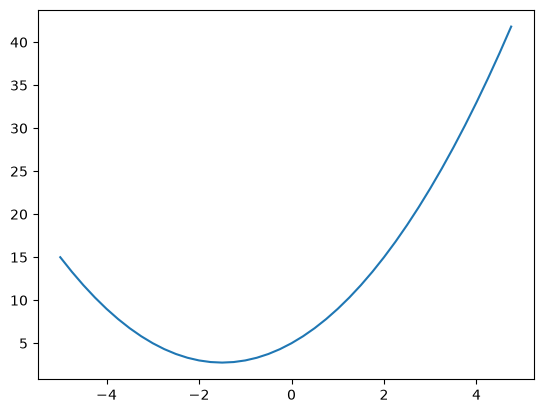

In [10]:
plt.plot(xs, ys)
plt.show()

## Derivative

The derivative of a function is defined as:

$$
\frac{dy}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}
$$

now the above function states: For any value x a small change in h will account for the direction of slope for change in value of y

Meaning how much the y will change for a change in x

So it tells how much the slope will be at that point

In [11]:
h = 0.0001
x = Value(3.0)

y = (f(x + h) - f(x)) / h

print(y)

Value(data=9.000100000022826, grad=0)


In [12]:
def fn(x):
    return 3 * x**2 + 3 * x + 5

[-2.69997000e+01 -2.54997000e+01 -2.39997000e+01 -2.24997000e+01
 -2.09997000e+01 -1.94997000e+01 -1.79997000e+01 -1.64997000e+01
 -1.49997000e+01 -1.34997000e+01 -1.19997000e+01 -1.04997000e+01
 -8.99970000e+00 -7.49970000e+00 -5.99970000e+00 -4.49970000e+00
 -2.99970000e+00 -1.49970000e+00  2.99999998e-04  1.50030000e+00
  3.00030000e+00  4.50030000e+00  6.00030000e+00  7.50030000e+00
  9.00030000e+00  1.05003000e+01  1.20003000e+01  1.35003000e+01
  1.50003000e+01  1.65003000e+01  1.80003000e+01  1.95003000e+01
  2.10003000e+01  2.25003000e+01  2.40003000e+01  2.55003000e+01
  2.70003000e+01  2.85003000e+01  3.00003000e+01  3.15003000e+01]


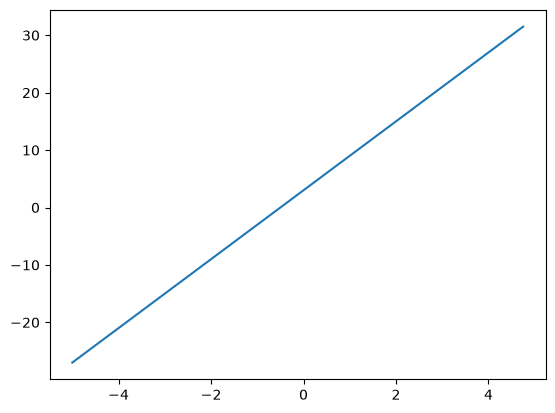

In [13]:
ys = (fn(xs + h) - fn(xs)) / h

print(ys)

plt.plot(xs, ys)
plt.show()

Going more complex

We will look at the following derevatives

1. with respect to a

In [14]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c

a += h  # we bump the value of a slightly

d2 = a * b + c

print("d1", d1)
print("d2", d2)

print("slope", (d2 - d1) / h)  # this is basically (f(x+h) - f(x))/h

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


2. with respect to b

In [15]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c

b += h  # we bump the value of a slightly

d2 = a * b + c

print("d1", d1)
print("d2", d2)

print("slope", (d2 - d1) / h)  # this is basically (f(x+h) - f(x))/h

d1 4.0
d2 4.0002
slope 2.0000000000042206


3. with respect to c

In [16]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c

c += h  # we bump the value of a slightly

d2 = a * b + c

print("d1", d1)
print("d2", d2)

print("slope", (d2 - d1) / h)  # this is basically (f(x+h) - f(x))/h

d1 4.0
d2 4.0001
slope 0.9999999999976694


The above vales can be verified by actually derivating the equation

# Neural Networks
NN have massive equations, and so to store those value we will be building the data-structures.

In [17]:
import math

## Class Value

In [ ]:
class Value:
    def __init__(self, data, _childern=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._prev = set(_childern)
        self._op = _op
        self.label = label
        # after step 2
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(
            self.data + other.data, (self, other), "+"
        )  # here we are creating new object for class value, so that the original data is not lost
        
        
        ### after step 2
        def _backward():
            # self.grad = 1.0 * out.grad
            # other.grad = 1.0 * out.grad
            ## after step 4
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
            
        out._backward = _backward
        
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), "*")
        
        ### after step 2
        def _backward():
            # self.grad = other.data * out.grad
            # other.grad = self.data * out.grad
            ### after step 4
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            
        out._backward = _backward
        
        return out

    # def __mul__(self,other): # in this function we loose the capability to store the metadata with the generated output, like operation used, operators used, etc.
    #     out  = self.data * other.data
    #     return out

    def tanh(self):
        x = self.data
        t = ((math.exp(2*x)-1)/(math.exp(2*x)+1)) # this is the value of tanh = (e^(2n)-1)/(e^(2n)+1)
        out = Value(t, (self,), "tanh", f"tanh activation on {self.label}")
        
        def _backward():
            # self.grad = (1 - t**2) * out.grad
            ### after step 4
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward
                
        return out


    ##### After step 3
    def backward(self):

        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                
                topo.append(v)

        build_topo(self)
        
        self.grad = 1.0 # base case

        for node in reversed(topo):
            node._backward()



a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")

print(a * b)
print(a + b)

print(a * b + c)
# d = a*b+c
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a * b
e.label = "e"
d = e + c
d.label = "d"
f = Value(-2.0, label="f")
L = d * f
L.label = "L"
L

Value(data=-6.0)
Value(data=-1.0)
Value(data=4.0)


Value(data=-8.0)

In [19]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [20]:
d._op

'+'

In [21]:
parents = list(d._prev)

# _prev stores the parent nodes as a set because only the connections in the
# computation graph matter, not their order. Since sets cannot be indexed
# (e.g., _prev[0]), we temporarily convert the set to a list so we can
# access and print the parent nodes for debugging and understanding.
print(f"{parents[0]} {d._op} {parents[1]} = {d}")

# The following would raise a TypeError because _prev is a set:
# print(f"{d._prev[0]} {d._op} {d._prev[1]} = {d}")

Value(data=10.0) + Value(data=-6.0) = Value(data=4.0)


### Scary visulaization

https://gitlab.com/api/v4/projects/4207231/packages/generic/graphviz-releases/15.1.0/windows_10_cmake_Release_Graphviz-15.1.0-win64.zip

- Link to download graphiz
- extract it
- then place the path of the bin folder in the following code

In [22]:
import os
# os.environ["PATH"] += r";C:\Graphviz-15.1.0-win64\bin"
os.environ["PATH"] += r";C:\Users\TRIO990019\Downloads\windows_10_cmake_Release_Graphviz-15.1.0-win32\Graphviz-15.1.0-win32\bin"

In [23]:
! dot -V

dot - graphviz version 15.1.0 (20260618.0150)


In [24]:
from graphviz import Digraph


def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad),
            shape="record",
        )
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

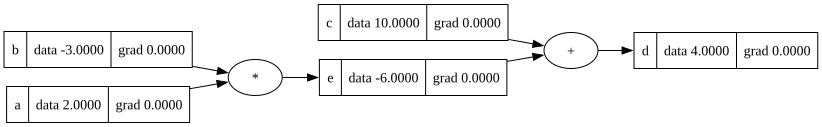

In [25]:
draw_dot(d)

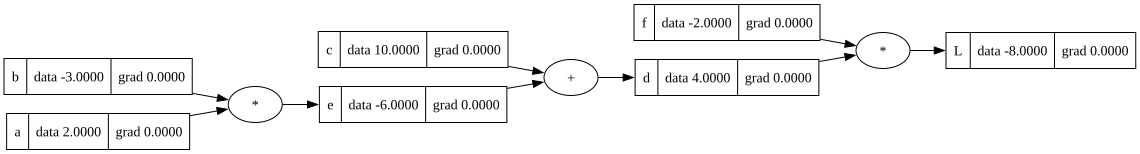

In [26]:
draw_dot(L)

Ok so here we can do manual backpropogation of the values and apply the grad in the values one by one, using the chane rule, which says:

when we know 

dx/de and de/dc

and we want to know

dx/dc = (dx/de) * (de/dc)

Lets go apply the manual back-propogation now:

### f(y) = (f(x+h) - f(x))/h

In [27]:
h = 0.001

In [28]:
L.grad = ((L.data + h) - L.data)/h

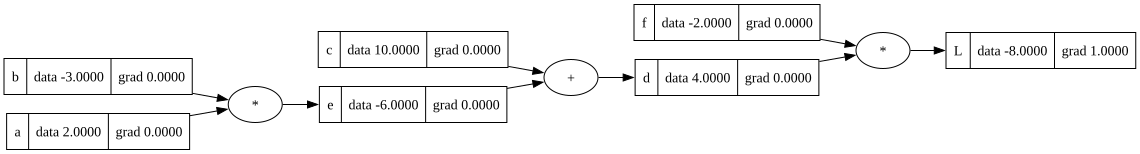

In [29]:
draw_dot(L)

Notice the value of grad in L it is now 1

Simiarlly when we apply the similar rule along with the chain rule to other data as well.

The following function can be used to understand the change manually

Or we can derive it using the formula

Or we can simply derivate the functions

In [30]:
# def lol():
  
#   h = 0.001
  
#   a = Value(2.0, label='a')
#   b = Value(-3.0, label='b')
#   c = Value(10.0, label='c')
#   e = a*b; e.label = 'e'
#   d = e + c; d.label = 'd'
#   f = Value(-2.0, label='f')
#   L = d * f; L.label = 'L'
#   L1 = L.data
  
#   a = Value(2.0, label='a')
#   b = Value(-3.0, label='b')
#   b.data += h
#   c = Value(10.0, label='c')
#   e = a*b; e.label = 'e'
#   d = e + c; d.label = 'd'
#   f = Value(-2.0, label='f')
#   L = d * f; L.label = 'L'
#   L2 = L.data
  
#   print((L2 - L1)/h)
  
# lol()


and after applying all those manual backpropagation we will get the following graph:

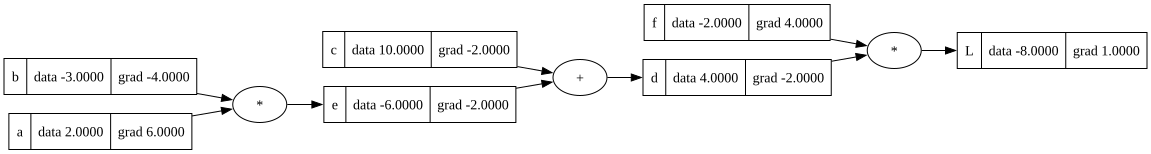

In [31]:
# using the formula of the deriavative

d.grad = -2.0
f.grad = 4.0

# here using derivative formula and appling the chain rule

c.grad = -2.0
e.grad = -2.0

a.grad = 6.0
b.grad = -4.0

draw_dot(L)

Ok now lets nudge the data values a little bit and see what happenes, theoretically for L to increase ( become less -ve ), we need to move in the direction of the gradient of L 

In [32]:
# we are nudging the values of a, b, c, f by a small amount in the direction of their gradients to minimize the loss L. This is a simple gradient descent step.
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


## Ok now for the neural networks we use the activaton function to adjust the weights

## This is the activation function

<img src="https://cs231n.github.io/assets/nn1/neuron_model.jpeg" width="700">


### Here we will use the tanh() activatio function

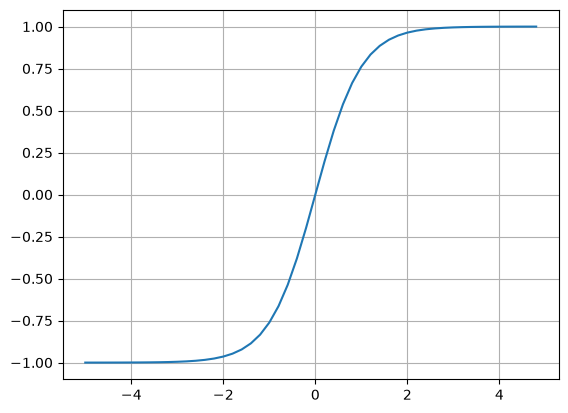

In [33]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)))
plt.grid()

Ok now for the above neuron lets manually work on providing the inputs and outputs
using tanh as the activation function

In the following we give the manual input for the values in the neuron
inputs, weights, bias and manually apply the activation function

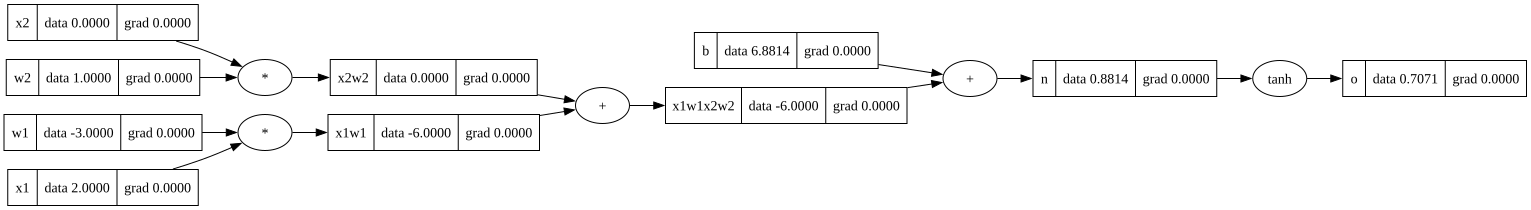

In [34]:
# input values x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# bias on the neuron
b = Value(6.8813735870195432, label="b") # optimized value of b 
# b = Value(8.0, label="b")
# applying the formula in the neuron
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = "x1w1"
x2w2 = x2*w2; x2w2.label = "x2w2"

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1x2w2"

n = x1w1x2w2 + b; n.label = "n" # this is the neuron out, then we apply the activation funciton to it

o = n.tanh(); o.label = "o" # output after applying the activation function

draw_dot(o)



- here for gradient we are most concerned are weights, since those are the only values that will be changing
- secondally this is the behaviour of the singel neuron, but in the original network there are multiple neurons

#### Now doing back-propogation

In [35]:
# base case
g.grad = 1.0

### Derivative of the Tanh Function

Given,

$$
o = \tanh(n)
$$

The derivative of the tanh function is

$$
\frac{do}{dn} = 1 - \tanh^2(n)
$$

Since

$$
o = \tanh(n),
$$

we can substitute \(o\) into the derivative:

$$
\frac{do}{dn} = 1 - o^2
$$

*Source: Wikipedia*

---

### Applying the Chain Rule in Backpropagation

The tanh node is not the final output of the computation graph. It passes its output to other operations, which eventually produce the final output \(O\).

Therefore, we want to compute

$$
\frac{dO}{dn}
$$

Using the chain rule,

$$
\frac{dO}{dn}
=
\frac{dO}{do}
\times
\frac{do}{dn}
$$

From the tanh derivative,

$$
\frac{do}{dn} = 1 - o^2
$$

Substituting this into the chain rule,

$$
\frac{dO}{dn}
=
\frac{dO}{do}
\times
(1-o^2)
$$

In Micrograd,

- `out.grad` stores the upstream gradient

$$
\frac{dO}{do}
$$

- The local derivative of the tanh node is

$$
1-o^2
$$

Therefore, the backward function becomes

```python
self.grad = (1 - t**2) * out.grad
```

where `t` is the value of `tanh(n)` computed during the forward pass.

---

### Why didn't we multiply by `out.grad` during manual backpropagation?

When manually computing gradients, we start from the final output itself by setting

```python
o.grad = 1.0
```

This means

$$
\frac{dO}{do}=1
$$

Therefore,

$$
\frac{dO}{dn}
=
1 \times (1-o^2)
=
1-o^2
$$

So, during manual backpropagation, multiplying by `out.grad` is unnecessary because `out.grad` is already equal to **1**. In the general implementation, however, `out.grad` can be any value, so it must always be multiplied according to the chain rule.

So manual backpropogation gives us:

In [36]:
# do/do
o.grad = 1.0

# do/dn = 1 * (1 - tanh^2(n)) = 1 * (1 - o^2)
n.grad = o.grad * (1 - o.data**2)


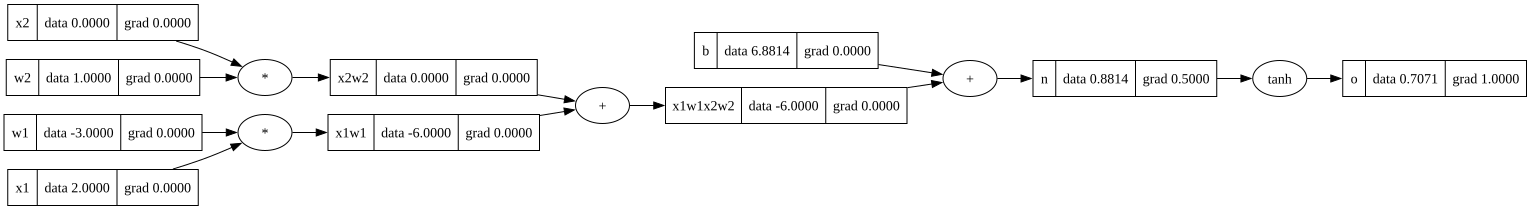

In [37]:
draw_dot(o)

### Gradient with respect to the bias ($b$)

Using the chain rule:

$$
\frac{\partial o}{\partial b}
=
\frac{\partial o}{\partial n}
\times
\frac{\partial n}{\partial b}
$$

Given:

$$
\frac{\partial o}{\partial n}=0.5
$$

The neuron output before activation is:

$$
n=x_1w_1+x_2w_2+b
$$

Differentiating with respect to $b$:

$$
\frac{\partial n}{\partial b}
=
\frac{\partial}{\partial b}(x_1w_1+x_2w_2+b)
=
0+0+1
=
1
$$

Therefore,

$$
\frac{\partial o}{\partial b}
=
0.5\times1
=
0.5
$$

**Final Answer**

$$
\boxed{\frac{\partial o}{\partial b}=0.5}
$$

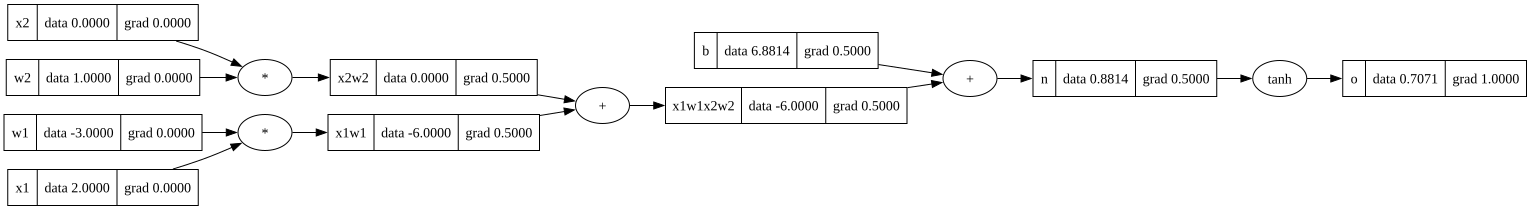

In [38]:
# do/db using the chain rule. And we can also say simple derivative since, n is liner function of b hence derivative of n with respect to b is 1.0
# do/dx1w1x2w2 same can be said for this as well

### b.grad = 1.0 * n.grad
### (x1w1x2w2.grad) = 1.0 * n.grad
b.grad = 0.5
x1w1x2w2.grad = 0.5

# using the same logic as above:

x2w2.grad = 0.5
x1w1.grad = 0.5

draw_dot(o)

Using the chain rule,

$$
\frac{\partial o}{\partial x_2}
=
\frac{\partial o}{\partial (x_2w_2)}
\times
\frac{\partial (x_2w_2)}{\partial x_2}
$$

Now,

$$
\frac{\partial o}{\partial (x_2w_2)} = 0.5
$$

Also,

$$
x_2w_2 = x_2 \times w_2
$$

Differentiating this equation with respect to $x_2$,

$$
\frac{\partial (x_2w_2)}{\partial x_2} = w_2 = 1.0
$$

Substituting these values into the main equation,

$$
\frac{\partial o}{\partial x_2}
=
0.5 \times 1.0
=
0.5
$$

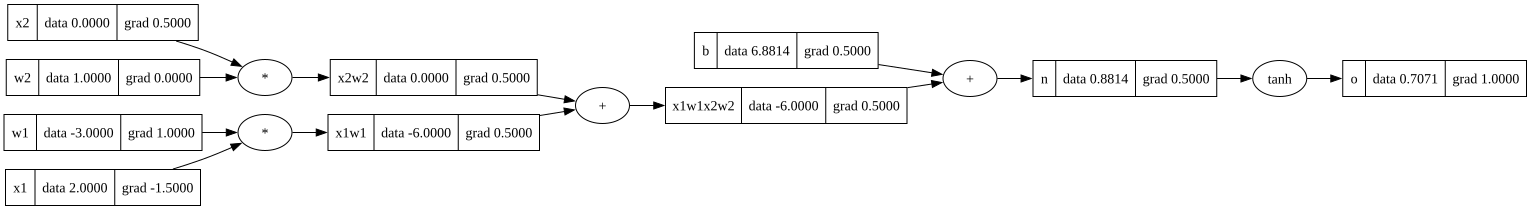

In [39]:
# so do/dx2, do/xw2, do/x1, do/dw1

x2.grad = 0.5 # x2.grad = w2.data * x2w2.grad
w2.grad = 0.0 # w2.grad = x2.data * x2w2.grad

x1.grad = -1.5 # x1.grad = w1.data * x1w1.grad
w1.grad = 1.0 # w1.grad = x1.data * x1w1.grad

draw_dot(o)

### Ok so from the above graph we conclude:

- x1 and x2 is data and will not change
- w2 = 0.0 meaning it does not have any influence on the loss function o
- w1 will increase the output of the neural proportianally 

# Step 2
### Now we will work on implemntating the backpropgation part automatically

In [40]:
# input values x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# bias on the neuron
b = Value(6.8813735870195432, label="b") # optimized value of b 
# b = Value(8.0, label="b")
# applying the formula in the neuron
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = "x1w1"
x2w2 = x2*w2; x2w2.label = "x2w2"

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1x2w2"

n = x1w1x2w2 + b; n.label = "n" # this is the neuron out, then we apply the activation funciton to it

o = n.tanh(); o.label = "o" # output after applying the activation function


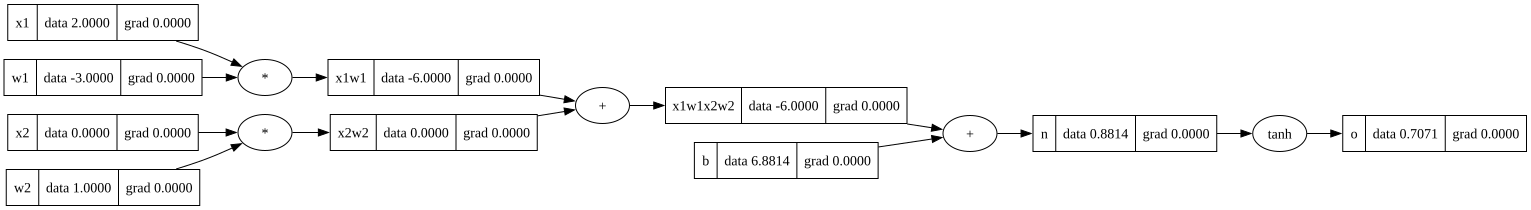

In [41]:
draw_dot(o)

Now here the out.grad in the function is marked 0.0       
so as a base case for the loss function we mark

out.grad = 1.0

In [42]:
o.grad = 1.0
o._backward()

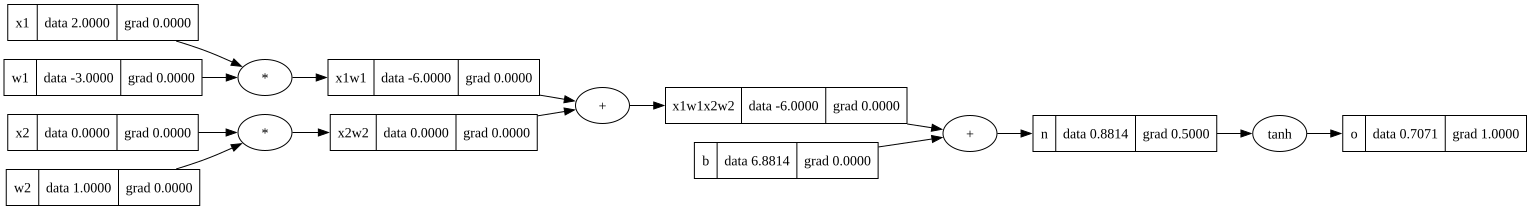

In [43]:
draw_dot(o)

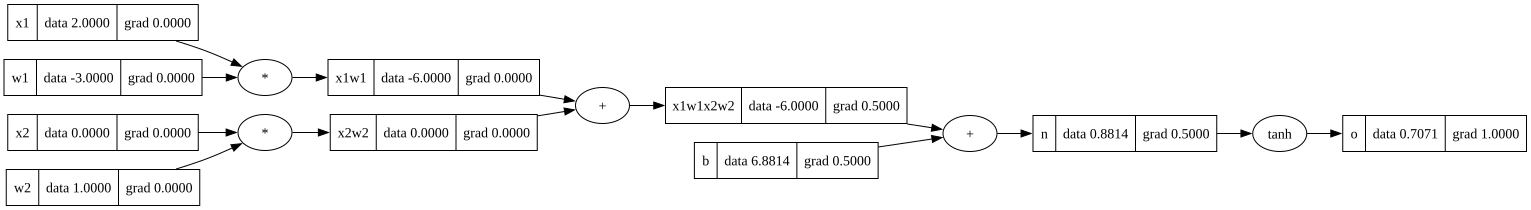

In [44]:
n._backward()
draw_dot(o)

In [45]:
x1w1x2w2._backward()
b._backward()

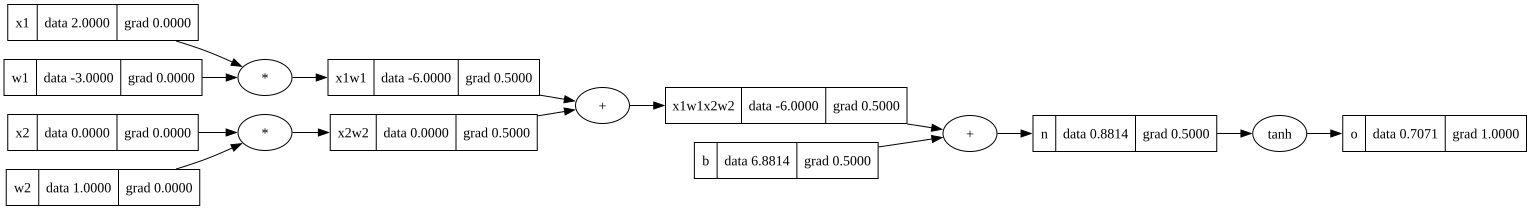

In [46]:
draw_dot(o)

In [47]:
x1w1._backward()
x2w2._backward()

In [48]:
x1w1._backward()

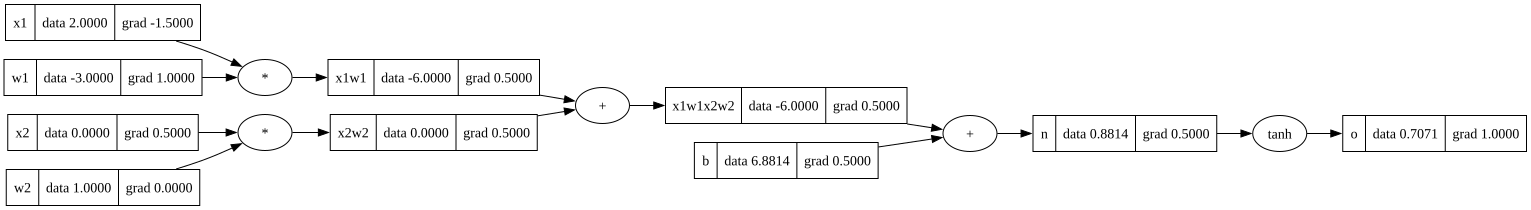

In [49]:
draw_dot(o)

# Automating the back propogation

### Topological Sorting

## This is the activation function

<img src="https://miro.medium.com/v2/resize:fit:1400/1*uMg_ojFXts2WZSjcZe4oRQ.png" width="700">


Topological sorting for Directed Acyclic Graph (DAG) is a linear ordering of vertices such that for every directed edge u→v, vertex u comes before v in the ordering. There may be several topological orderings for a graph.

- Applies only to DAGs (Directed Acyclic Graphs), and is not possible for cyclic or undirected graphs.
- It represents dependency ordering between vertices which is different from normal DFS or BFS traversals.
- Used in problems like task scheduling, build order, course prerequisite ordering, etc.

*source GFG, Wikepedia, Medium*

In [50]:

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)
print(topo)

print("\n")

for i in topo:
    print(i.label,end=", ")

[Value(data=6.881373587019543), Value(data=1.0), Value(data=0.0), Value(data=0.0), Value(data=2.0), Value(data=-3.0), Value(data=-6.0), Value(data=-6.0), Value(data=0.8813735870195432), Value(data=0.7071067811865476)]


b, w2, x2, x2w2, x1, w1, x1w1, x1w1x2w2, n, o, 

So now we have the nodes in the order.

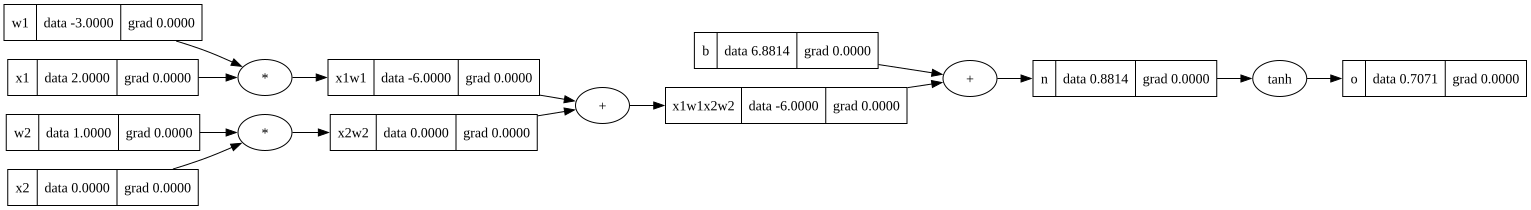

In [51]:
# Resetting the values

# input values x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# bias on the neuron
b = Value(6.8813735870195432, label="b") # optimized value of b 
# b = Value(8.0, label="b")
# applying the formula in the neuron
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = "x1w1"
x2w2 = x2*w2; x2w2.label = "x2w2"

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1x2w2"

n = x1w1x2w2 + b; n.label = "n" # this is the neuron out, then we apply the activation funciton to it

o = n.tanh(); o.label = "o" # output after applying the activation function

draw_dot(o)

applying the loop in the topologically sorted nodes in reverse

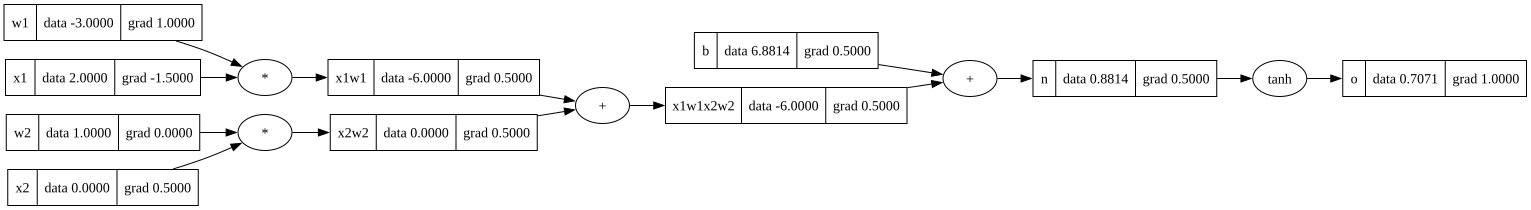

In [52]:
o.grad = 1.0 # base case

topo = []
visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        
        topo.append(v)

build_topo(o)

for node in reversed(topo):
    node._backward()

draw_dot(o)

# Step 3

Now we shift the loop in to value class, so that it is not laying around

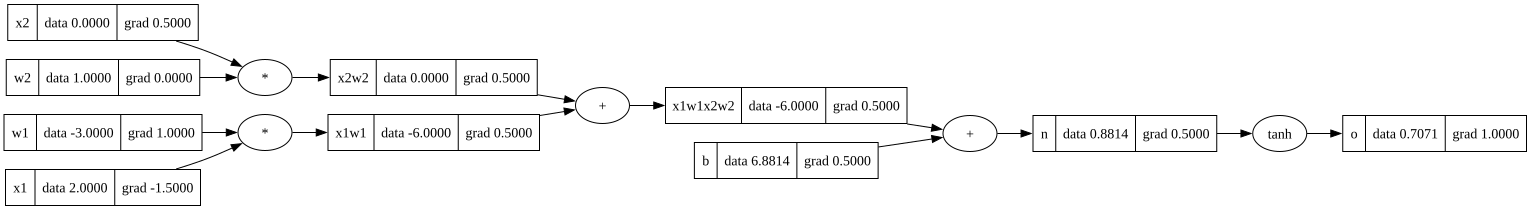

In [54]:
# Resetting the values

# input values x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# bias on the neuron
b = Value(6.8813735870195432, label="b") # optimized value of b 
# b = Value(8.0, label="b")
# applying the formula in the neuron
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = "x1w1"
x2w2 = x2*w2; x2w2.label = "x2w2"

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1x2w2"

n = x1w1x2w2 + b; n.label = "n" # this is the neuron out, then we apply the activation funciton to it

o = n.tanh(); o.label = "o" # output after applying the activation function

o.backward()

draw_dot(o)

# Step 4

Issue in the existing approach, if the same node is parent to 2 different nodes, then during back-propogation         
One nodes writes their gradients, but then next node over-rides their gradients.         
Meaning the true gradients are not stored here

Meaninging for:

<p align="center">
  <img src="images/Screenshot1.png" width="400">
</p>

Whereas the correct one is:

<p align="center">
  <img src="images/Screenshot2.png" width="400">
</p>

Observe in the second image the gradint is 2 which is actually correct if we think it intutively for the above codes

The solution to this is in the multi-variete chain rule     
it states the the **Gradients accumulate**         

Meaning in case of multiply:  
## Solution

Instead of overwriting the gradient:

```python
self.grad = other.data * out.grad
other.grad = self.data * out.grad
```

we **accumulate** it:

```python
self.grad += other.data * out.grad
other.grad += self.data * out.grad
```
